<a href="https://colab.research.google.com/github/andreslill/mosquito-season-suitability/blob/main/methodology_and_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Methodology & Validation: Mosquito Suitability Model

This notebook documents the methodology, external validation, and limitations of the mosquito climate suitability model. Sections 1–12 validate suitability scores against occurrence records from Kraemer et al. (2015).
Sections 13–18 cover comparison with independent transmission models, photoperiod parameter validation, confirmed European distribution, model limitations, potential extensions, and references.

## Validation

**Approach:**
1. Aggregate monthly suitability scores to city-level metrics (peak month, season length, mean active-month score)
2. Spatial join: for each city, check whether any Kraemer occurrence falls within a given radius
3. Compare score distributions between presence and absence groups
4. Quantify discrimination with ROC/AUC

**Data:**
- `mosquito_suitability.csv`: 1,421 cities × 12 months, ERA5 1991–2020 climate normals
- `kraemer_occurrences.csv`: 42,066 occurrence records, 1958–2014, both species

**Model components:** Core functions (Magnus approximation, sigmoid PhotoFactor) are validated with unit tests in `mosquito_suitability_pipeline.ipynb`.

**Key limitation:** Kraemer records go up to 2014; suitability scores are based on 1991–2020 climate normals. This temporal mismatch is unavoidable but acceptable: climate normals are stable enough over this window, and the comparison is between long-run climatic suitability and observed establishment, not short-term forecasting.

### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

RADIUS_KM = 50  # matching radius for spatial join
EARTH_RADIUS_KM = 6371.0

print('Libraries loaded.')

Libraries loaded.


### 2. Load Data

`mosquito_suitability.csv` is the direct output of `mosquito_suitability_pipeline.ipynb`.
`kraemer_occurrences.csv` was derived from the raw Kraemer et al. (2015/2017) dataset —
see the commented preprocessing cell below. Both files are included in the repository
and can be loaded directly.

For `kraemer_occurrences.csv`, the harmonization steps were:
- Column renaming: `VECTOR` → `species`, `Y`/`X` → `lat`/`lon`, `COUNTRY` → `country_name`, `COUNTRY_ID` → `iso3`
- Species label standardization: `'Aedes aegypti'` → `'Ae. aegypti'`, `'Aedes albopictus'` → `'Ae. albopictus'`
- Addition of `is_point` flag: `True` where `location_type == 'point'`, `False` for polygon centroids
- Rows without coordinates dropped; `year` cast to nullable integer

The `is_point` flag is used in Section 3 to restrict the spatial join to point-level records only, excluding polygon centroids that may represent regions up to hundreds of km wide.

In [ ]:
# ── KRAEMER PREPROCESSING ─────────────────────────────────────────────────────
# This cell documents how kraemer_occurrences.csv was derived from the raw
# Kraemer et al. (2015/2017) dataset. The processed file is already included
# in the repository — this cell does not need to be run.
#
# Raw source: aegypti_albopictus.csv (Kraemer et al. 2015/2017, Dryad)
# https://doi.org/10.5061/dryad.47v3c

# import pandas as pd
#
# kraemer_raw = pd.read_csv("aegypti_albopictus.csv")
#
# kraemer = pd.DataFrame({
#     "species":       kraemer_raw["VECTOR"],
#     "lat":           kraemer_raw["Y"],
#     "lon":           kraemer_raw["X"],
#     "year":          kraemer_raw["YEAR"],
#     "country_name":  kraemer_raw["COUNTRY"],
#     "iso3":          kraemer_raw["COUNTRY_ID"],
#     "location_type": kraemer_raw["LOCATION_TYPE"],
#     "source":        "Kraemer et al. 2015/2017",
# })
#
# SPECIES_MAP = {
#     "Aedes aegypti":    "Ae. aegypti",
#     "Aedes albopictus": "Ae. albopictus",
# }
# kraemer["species"] = kraemer["species"].map(SPECIES_MAP).fillna(kraemer["species"])
# kraemer["is_point"] = kraemer["location_type"] == "point"
# kraemer = kraemer.dropna(subset=["lat", "lon"])
# kraemer["year"] = pd.to_numeric(kraemer["year"], errors="coerce").astype("Int64")
#
# kraemer.to_csv("kraemer_occurrences.csv", index=False)

In [3]:
# Load both suitability CSVs for comparison
suit         = pd.read_csv('mosquito_suitability.csv')          # original (old photoperiod gate)
suit_updated = pd.read_csv('mosquito_suitability_updated.csv')  # revised (new photoperiod gate)
kraemer      = pd.read_csv('kraemer_occurrences.csv')

print(f'Suitability (original):  {len(suit):,}  ({suit["city"].nunique()} cities)')
print(f'Suitability (updated):   {len(suit_updated):,}  ({suit_updated["city"].nunique()} cities)')
print(f'Kraemer records:         {len(kraemer):,}')
print()
print('Kraemer species breakdown:')
print(kraemer['species'].value_counts())
print()
print('Kraemer location_type breakdown:')
print(kraemer['location_type'].value_counts())

Suitability (original):  17,076  (1418 cities)
Suitability (updated):   17,076  (1418 cities)
Kraemer records:         42,066

Kraemer species breakdown:
species
Ae. albopictus    22137
Ae. aegypti       19929
Name: count, dtype: int64

Kraemer location_type breakdown:
location_type
point               31271
polygon              9558
Less than 25km        248
Less than 100km       246
Less than 10km        190
Less than 10 km        45
Less than 100 km       18
Less than 25 km        10
Name: count, dtype: int64


### 3. Aggregate Suitability to City Level

From 12 monthly rows per city, derive city-level metrics per species:
- **`peak_score`**: maximum monthly suitability (best-month performance)
- **`season_months_02/03/04`**: number of months exceeding a suitability threshold of 0.2, 0.3, or 0.4 respectively. A threshold of `> 0` was deliberately avoided: for a multiplicative score, values just above zero can reflect negligible climatic suitability while still being counted as active months, which distorts season length. The three thresholds correspond directly to the filter options available in the Tableau dashboard, keeping the validation consistent with the published tool. Multiple plausible thresholds are tested to confirm that the result does not depend on any single threshold choice.
- **`mean_active_score`**: mean suitability across months with score >= 0.2 (the lowest dashboard threshold)

In [6]:
def city_metrics(df, species_col):
    """Aggregate monthly scores to city-level metrics."""
    grp = df.groupby(['city', 'country', 'lat', 'lon'])
    peak = grp[species_col].max().rename('peak_score')
    season_02 = (df[species_col] >= 0.2).groupby(
        [df['city'], df['country'], df['lat'], df['lon']]
    ).sum().rename('season_months_02')
    season_03 = (df[species_col] >= 0.3).groupby(
        [df['city'], df['country'], df['lat'], df['lon']]
    ).sum().rename('season_months_03')
    season_04 = (df[species_col] >= 0.4).groupby(
        [df['city'], df['country'], df['lat'], df['lon']]
    ).sum().rename('season_months_04')
    mean_active = df[df[species_col] >= 0.2].groupby(
        ['city', 'country', 'lat', 'lon']
    )[species_col].mean().rename('mean_active_score')
    result = pd.concat([peak, season_02, season_03, season_04, mean_active], axis=1).reset_index()
    result['mean_active_score'] = result['mean_active_score'].fillna(0)
    return result

# Compute city-level metrics for both versions
cities_aeg         = city_metrics(suit,         'suitability_score_aegypti')
cities_alb         = city_metrics(suit,         'suitability_score_albopictus')
cities_aeg_updated = city_metrics(suit_updated, 'suitability_score_aegypti')
cities_alb_updated = city_metrics(suit_updated, 'suitability_score_albopictus')

print('Ae. albopictus city metrics (original):')
print(cities_alb[['peak_score','season_months_02','season_months_03','season_months_04']].describe().round(3))
print()
print('Ae. albopictus city metrics (updated):')
print(cities_alb_updated[['peak_score','season_months_02','season_months_03','season_months_04']].describe().round(3))

Ae. albopictus city metrics (original):
       peak_score  season_months_02  season_months_03  season_months_04
count    1423.000          1423.000          1423.000          1423.000
mean        0.782             7.074             6.425             5.580
std         0.191             3.333             3.506             3.737
min         0.000             0.000             0.000             0.000
25%         0.661             5.000             4.000             3.000
50%         0.837             6.000             5.000             4.000
75%         0.935            11.000             9.000             8.000
max         1.000            12.000            12.000            12.000

Ae. albopictus city metrics (updated):
       peak_score  season_months_02  season_months_03  season_months_04
count    1423.000          1423.000          1423.000          1423.000
mean        0.778             6.218             5.665             5.098
std         0.204             3.813             3.855   

### 4. Spatial Join: Assign Presence/Absence Labels

For each city, check whether any Kraemer occurrence record falls within `RADIUS_KM`.

**Design choices:**
- Only `is_point == True` records are used. Polygon centroids can represent regions hundreds of km wide, which would introduce false positives at city level.
- Both species are handled separately.
- The join is done with a 3D unit-sphere kd-tree (fast, accurate for any lat/lon range).

In [15]:
def latlon_to_xyz(lat_deg, lon_deg):
    """Convert lat/lon (degrees) to unit-sphere XYZ."""
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.column_stack([x, y, z])

def spatial_presence_labels(city_df, occ_df, radius_km=50):
    """
    For each city in city_df, assign presence=1 if any occurrence in occ_df
    falls within radius_km. Uses cKDTree on unit sphere.
    """
    # chord length threshold on unit sphere
    chord_threshold = 2 * np.sin(np.radians(radius_km / EARTH_RADIUS_KM / 2))

    city_xyz = latlon_to_xyz(city_df['lat'].values, city_df['lon'].values)
    occ_xyz  = latlon_to_xyz(occ_df['lat'].values, occ_df['lon'].values)

    tree = cKDTree(occ_xyz)
    # query: for each city, find nearest occurrence
    dist, _ = tree.query(city_xyz, k=1)

    presence = (dist <= chord_threshold).astype(int)
    return presence

# Filter to point-only records per species
k_aeg = kraemer[(kraemer['species'] == 'Ae. aegypti') & (kraemer['is_point'] == True)].dropna(subset=['lat','lon'])
k_alb = kraemer[(kraemer['species'] == 'Ae. albopictus') & (kraemer['is_point'] == True)].dropna(subset=['lat','lon'])

print(f'Kraemer point records used: Ae. aegypti: {len(k_aeg):,} | Ae. albopictus: {len(k_alb):,}')

cities_aeg['presence'] = spatial_presence_labels(cities_aeg, k_aeg, radius_km=RADIUS_KM)
cities_alb['presence'] = spatial_presence_labels(cities_alb, k_alb, radius_km=RADIUS_KM)

for label, df in [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]:
    n1 = df['presence'].sum()
    n0 = len(df) - n1
    print(f'{label}: {n1} presence cities, {n0} absence cities  ({100*n1/len(df):.1f}% presence rate)')

cities_aeg_updated['presence'] = spatial_presence_labels(cities_aeg_updated, k_aeg, radius_km=RADIUS_KM)
cities_alb_updated['presence'] = spatial_presence_labels(cities_alb_updated, k_alb, radius_km=RADIUS_KM)

Kraemer point records used: Ae. aegypti: 13,991 | Ae. albopictus: 17,280
Ae. aegypti: 71 presence cities, 1352 absence cities  (5.0% presence rate)
Ae. albopictus: 23 presence cities, 1400 absence cities  (1.6% presence rate)


### 5. Sensitivity Analysis: Radius Choice

The 50 km radius is a modelling decision. The table below shows how both presence rate and AUC (for `season_months_02`, the strongest discriminator) change across radii. Stable AUC across radii indicates that the main conclusions do not hinge on the choice of 50 km.

In [8]:
radii = [25, 50, 75, 100, 150]
results = []
for r in radii:
    for label, city_df, occ_df in [('Ae. aegypti', cities_aeg, k_aeg), ('Ae. albopictus', cities_alb, k_alb)]:
        pres_labels = spatial_presence_labels(city_df, occ_df, radius_km=r)
        n_pres = pres_labels.sum()
        # AUC for season_months_02 at this radius
        tmp = city_df.copy()
        tmp['presence'] = pres_labels
        if tmp['presence'].sum() > 0:
            fpr, tpr, _ = roc_curve(tmp['presence'], tmp['season_months_02'])
            roc_auc = round(auc(fpr, tpr), 3)
        else:
            roc_auc = None
        results.append({'radius_km': r, 'species': label,
                        'n_presence': n_pres,
                        'pct_presence': round(100*n_pres/len(city_df), 1),
                        'AUC_season_02': roc_auc})

print(pd.DataFrame(results).to_string(index=False))

 radius_km        species  n_presence  pct_presence  AUC_season_02
        25    Ae. aegypti          28           2.0          0.799
        25 Ae. albopictus           7           0.5          0.614
        50    Ae. aegypti          71           5.0          0.835
        50 Ae. albopictus          23           1.6          0.743
        75    Ae. aegypti         109           7.7          0.844
        75 Ae. albopictus          39           2.7          0.750
       100    Ae. aegypti         136           9.6          0.848
       100 Ae. albopictus          52           3.7          0.710
       150    Ae. aegypti         167          11.7          0.851
       150 Ae. albopictus          82           5.8          0.726


### 6. Distribution Comparison: Presence vs. Absence-Labelled Cities

Visualise and test whether suitability scores differ between presence-labelled and absence-labelled cities. Note that absence-labelled here means no Kraemer point record within 50 km, not confirmed biological absence. The negative class is noisy and should be interpreted accordingly.

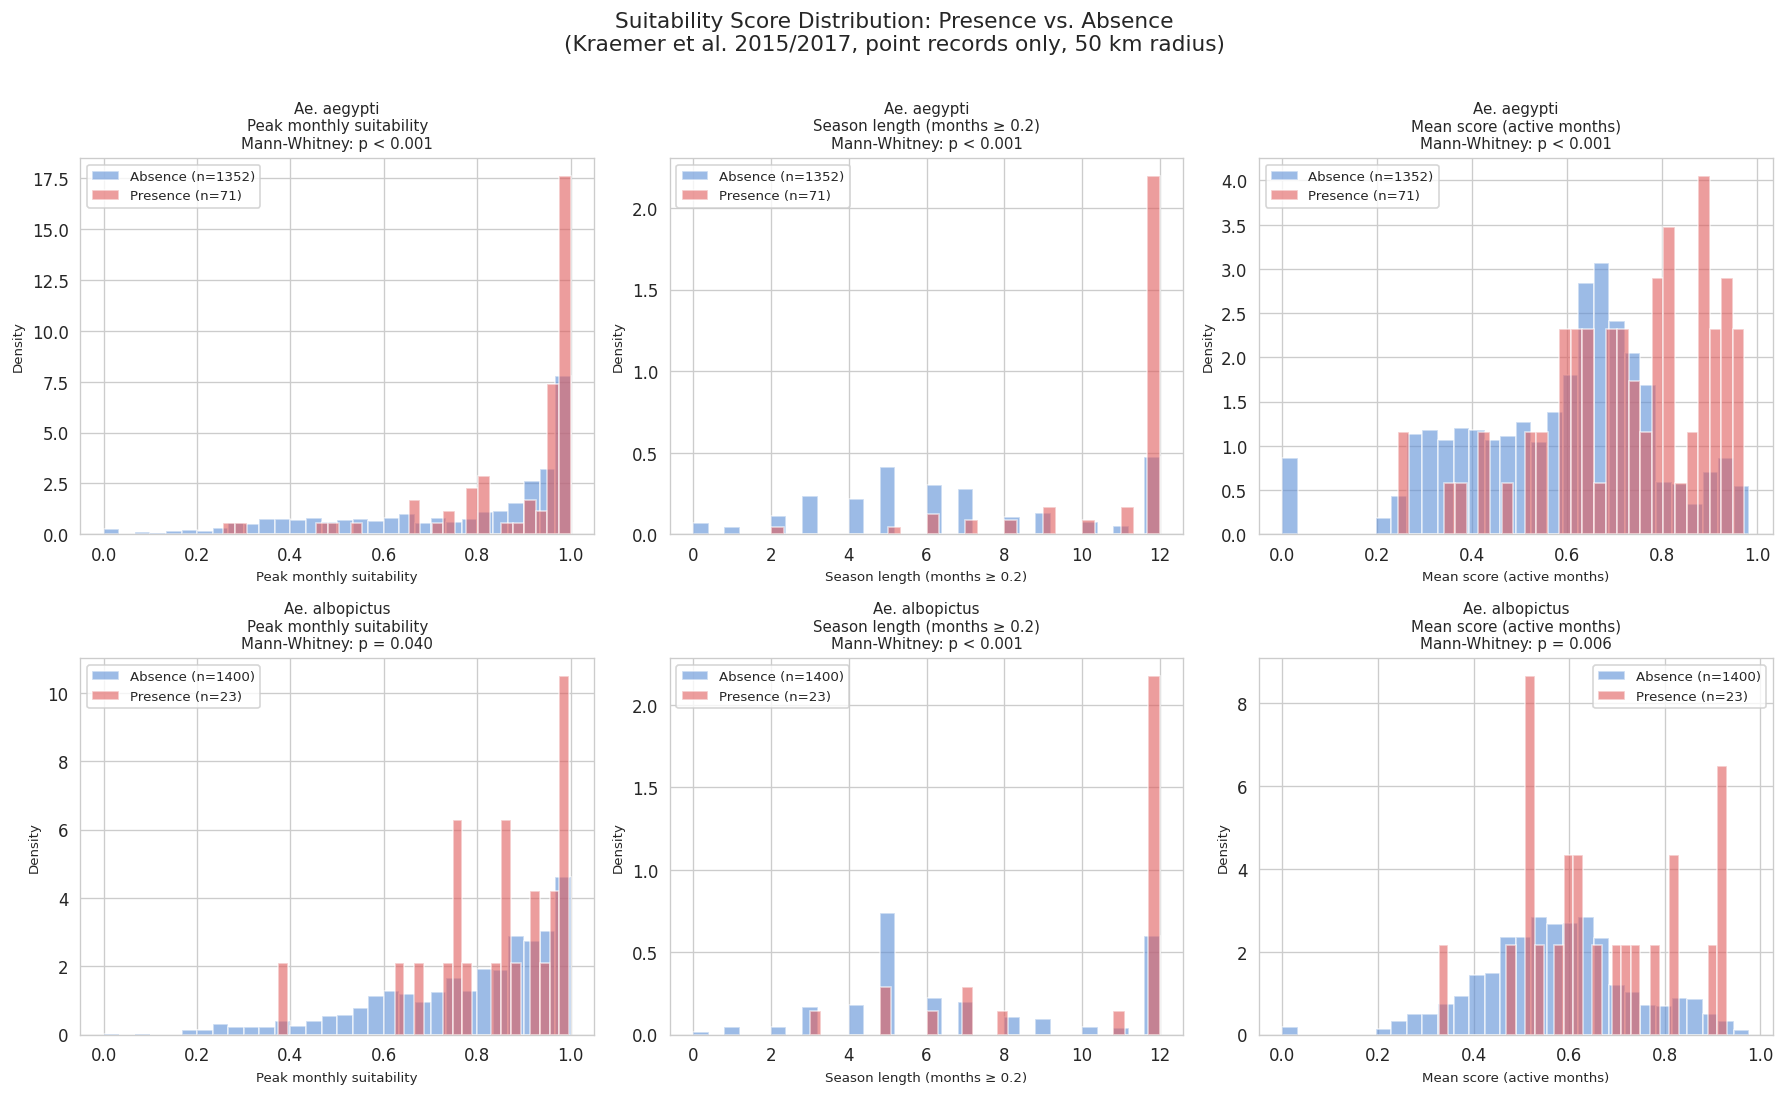

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Suitability Score Distribution: Presence vs. Absence\n(Kraemer et al. 2015/2017, point records only, 50 km radius)',
             fontsize=13, y=1.01)

metrics = ['peak_score', 'season_months_02', 'mean_active_score']
xlabels = ['Peak monthly suitability', 'Season length (months ≥ 0.2)', 'Mean score (active months)']
colors = {'presence': '#e05c5c', 'absence': '#5b8ed6'}

for row, (species_label, df) in enumerate([('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]):
    pres = df[df['presence'] == 1]
    abs_ = df[df['presence'] == 0]

    for col, (metric, xlabel) in enumerate(zip(metrics, xlabels)):
        ax = axes[row, col]

        ax.hist(abs_[metric], bins=30, alpha=0.6, color=colors['absence'],
                density=True, label=f'Absence (n={len(abs_)})')
        ax.hist(pres[metric], bins=30, alpha=0.6, color=colors['presence'],
                density=True, label=f'Presence (n={len(pres)})')

        # Mann-Whitney U test
        stat, p = stats.mannwhitneyu(pres[metric], abs_[metric], alternative='greater')
        p_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
        ax.set_title(f'{species_label}\n{xlabel}\nMann-Whitney: {p_str}', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel('Density', fontsize=8)

plt.tight_layout()
plt.savefig('fig_01_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Boxplots with Effect Size (Cohen's d)

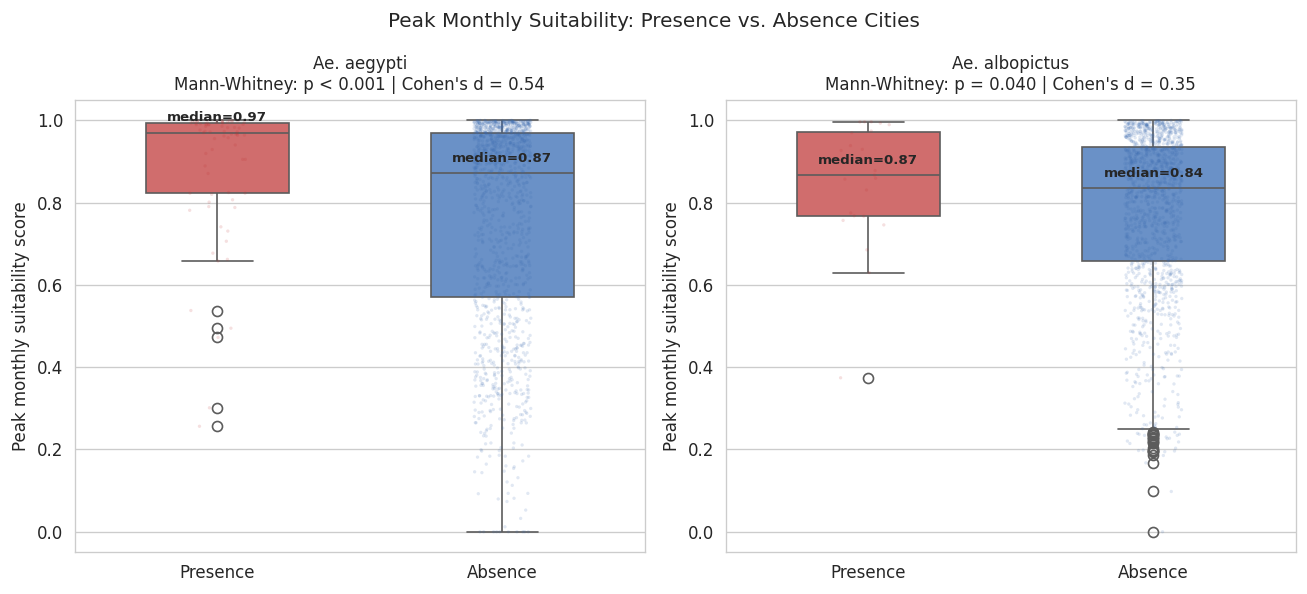

In [10]:
def cohens_d(a, b):
    """Pooled Cohen's d for two independent samples."""
    pooled_std = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Peak Monthly Suitability: Presence vs. Absence Cities', fontsize=12)

for ax, (species_label, df) in zip(axes, [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]):
    pres = df[df['presence'] == 1]['peak_score']
    abs_ = df[df['presence'] == 0]['peak_score']

    data_bp = pd.DataFrame({
        'peak_score': pd.concat([pres, abs_]),
        'group': ['Presence']*len(pres) + ['Absence']*len(abs_)
    })

    sns.boxplot(data=data_bp, x='group', y='peak_score', ax=ax,
                palette={'Presence': '#e05c5c', 'Absence': '#5b8ed6'},
                order=['Presence', 'Absence'], width=0.5)
    sns.stripplot(data=data_bp, x='group', y='peak_score', ax=ax,
                  palette={'Presence': '#c03030', 'Absence': '#3a6ab0'},
                  order=['Presence', 'Absence'], alpha=0.15, size=2, jitter=True)

    stat, p = stats.mannwhitneyu(pres, abs_, alternative='greater')
    d = cohens_d(pres, abs_)
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'

    ax.set_title(f'{species_label}\nMann-Whitney: {p_str} | Cohen\'s d = {d:.2f}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Peak monthly suitability score')

    # Annotate medians
    for i, (group, values) in enumerate([('Presence', pres), ('Absence', abs_)]):
        med = values.median()
        ax.text(i, med + 0.02, f'median={med:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. ROC / AUC Analysis

AUC measures how well the suitability score discriminates between presence and absence cities. AUC = 0.5 is random; AUC = 1.0 is perfect. An AUC > 0.70 is generally considered acceptable discrimination in many applied classification settings, though this threshold is context-dependent. Ecological niche models typically produce lower AUC values than models with clean, confirmed absence data, partly because absence records in sparse global datasets often reflect surveillance gaps rather than confirmed biological absence.

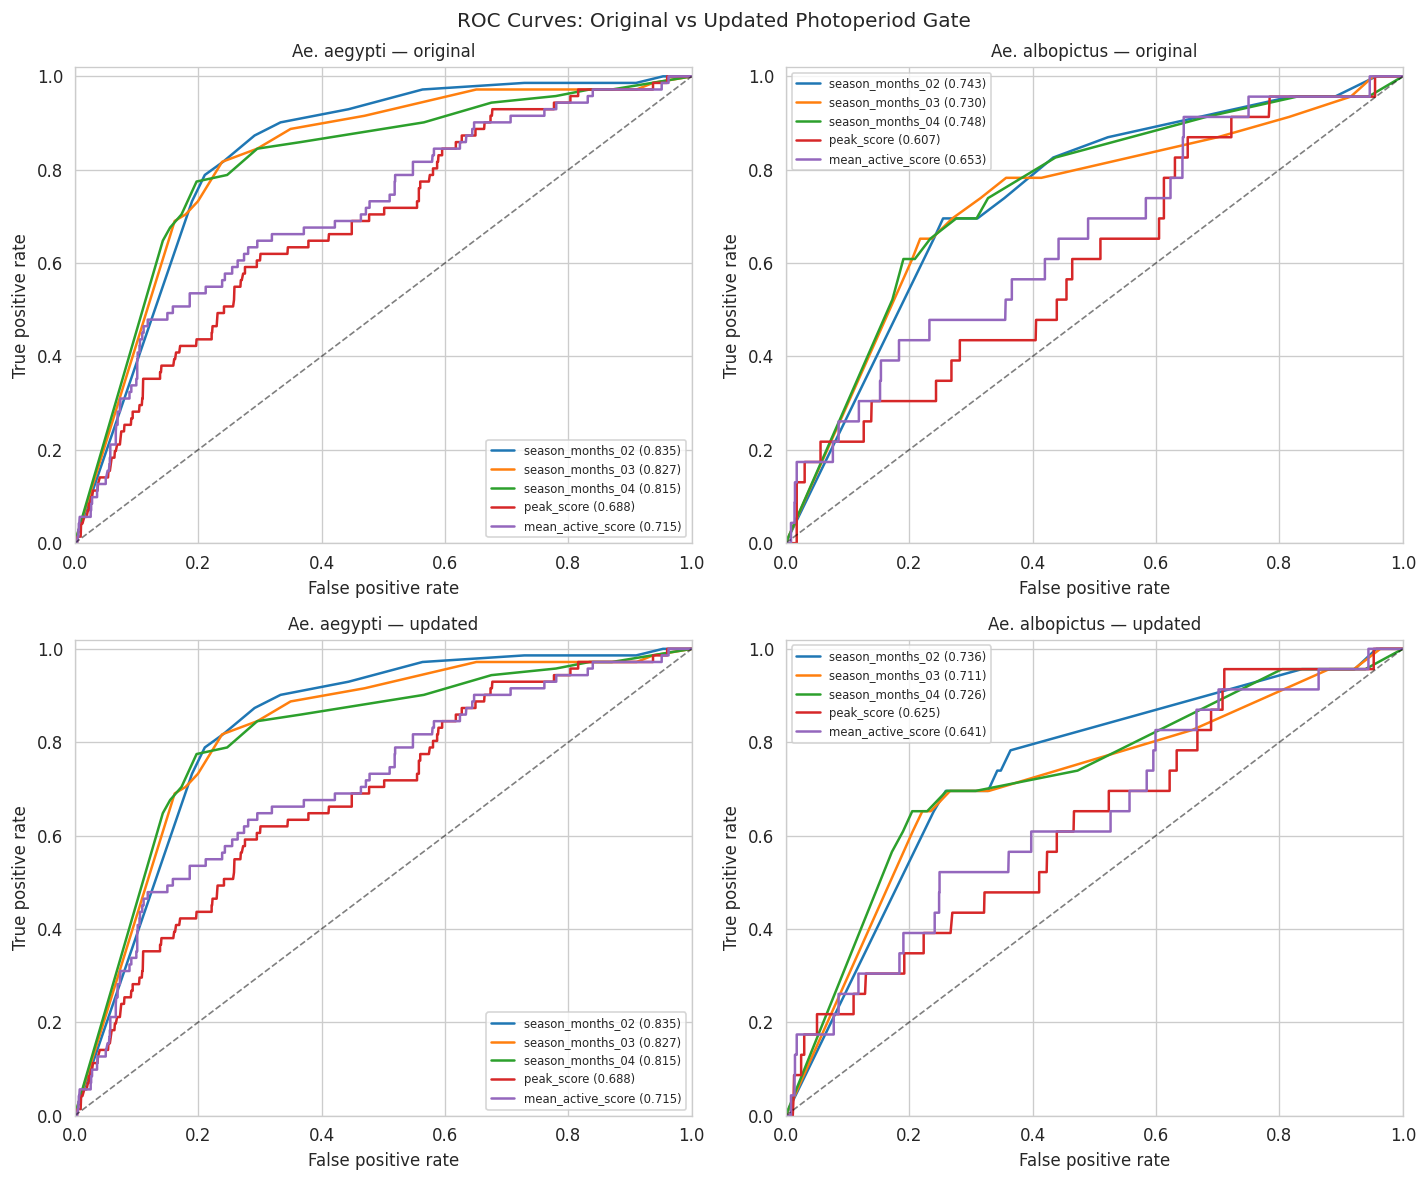

Saved: fig_03_roc_curves_comparison.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ROC Curves: Original vs Updated Photoperiod Gate', fontsize=12)

pairs = [
    (axes[0,0], 'Ae. aegypti',    cities_aeg,         'original'),
    (axes[0,1], 'Ae. albopictus', cities_alb,         'original'),
    (axes[1,0], 'Ae. aegypti',    cities_aeg_updated, 'updated'),
    (axes[1,1], 'Ae. albopictus', cities_alb_updated, 'updated'),
]

COLORS = {'season_months_02': '#1f77b4', 'season_months_03': '#ff7f0e',
          'season_months_04': '#2ca02c', 'peak_score': '#d62728',
          'mean_active_score': '#9467bd'}

for ax, species_label, df, version in pairs:
    for metric, color in COLORS.items():
        fpr, tpr, _ = roc_curve(df['presence'], df[metric])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{metric} ({roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(f'{species_label} — {version}', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig('fig_03_roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_03_roc_curves_comparison.png')


### 9. Summary Statistics Table

### 9. Summary Statistics Table: Original vs Updated

The table below computes AUC and effect size metrics for both the original and the updated photoperiod gate, using the same Kraemer occurrence records, spatial join, and threshold definitions. The `delta` column shows AUC(updated) − AUC(original).

**Interpretation:** A positive delta means the updated function improves discrimination. A delta near zero confirms the revision does not harm predictive performance. The primary criterion for accepting the revision is biological plausibility, not AUC improvement — see `photoperiod_parameter_selection.ipynb` for the full rationale.

In [17]:
# ORIGINAL
rows = []
for species_label, df in [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]:
    pres = df[df['presence'] == 1]
    abs_ = df[df['presence'] == 0]
    for metric in ['peak_score', 'season_months_02', 'season_months_03', 'season_months_04', 'mean_active_score']:
        stat, p = stats.mannwhitneyu(pres[metric], abs_[metric], alternative='greater')
        d = cohens_d(pres[metric], abs_[metric])
        fpr, tpr, _ = roc_curve(df['presence'], df[metric])
        roc_auc = auc(fpr, tpr)
        rows.append({'Version': 'original', 'Species': species_label, 'Metric': metric,
                     'Presence n': len(pres), 'Absence n': len(abs_),
                     'Presence median': round(pres[metric].median(), 3),
                     'Absence median': round(abs_[metric].median(), 3),
                     'MW p-value': '< 0.001' if p < 0.001 else round(p, 4),
                     "Cohen's d": round(d, 3), 'AUC': round(roc_auc, 3)})

# UPDATED
for species_label, df in [('Ae. aegypti', cities_aeg_updated), ('Ae. albopictus', cities_alb_updated)]:
    pres = df[df['presence'] == 1]
    abs_ = df[df['presence'] == 0]
    for metric in ['peak_score', 'season_months_02', 'season_months_03', 'season_months_04', 'mean_active_score']:
        stat, p = stats.mannwhitneyu(pres[metric], abs_[metric], alternative='greater')
        d = cohens_d(pres[metric], abs_[metric])
        fpr, tpr, _ = roc_curve(df['presence'], df[metric])
        roc_auc = auc(fpr, tpr)
        rows.append({'Version': 'updated', 'Species': species_label, 'Metric': metric,
                     'Presence n': len(pres), 'Absence n': len(abs_),
                     'Presence median': round(pres[metric].median(), 3),
                     'Absence median': round(abs_[metric].median(), 3),
                     'MW p-value': '< 0.001' if p < 0.001 else round(p, 4),
                     "Cohen's d": round(d, 3), 'AUC': round(roc_auc, 3)})

summary = pd.DataFrame(rows)
summary.to_csv('validation_summary_comparison.csv', index=False)

# ── COMPARISON TABLE: AUC only ────────────────────────────────────────────────
print('=== AUC comparison: original vs updated ===')
pivot = summary.pivot_table(index=['Species','Metric'], columns='Version', values='AUC')
pivot['delta'] = (pivot['updated'] - pivot['original']).round(3)
print(pivot.to_string())
print()
print('Full summary saved: validation_summary_comparison.csv')


=== AUC comparison: original vs updated ===
Version                           original  updated  delta
Species        Metric                                     
Ae. aegypti    mean_active_score     0.715    0.715  0.000
               peak_score            0.688    0.688  0.000
               season_months_02      0.835    0.835  0.000
               season_months_03      0.827    0.827  0.000
               season_months_04      0.815    0.815  0.000
Ae. albopictus mean_active_score     0.653    0.641 -0.012
               peak_score            0.607    0.625  0.018
               season_months_02      0.743    0.736 -0.007
               season_months_03      0.730    0.711 -0.019
               season_months_04      0.748    0.726 -0.022

Full summary saved: validation_summary_comparison.csv


### 10. Geographic Sanity Check

Plot presence/absence cities on a world map to verify the spatial join looks correct.

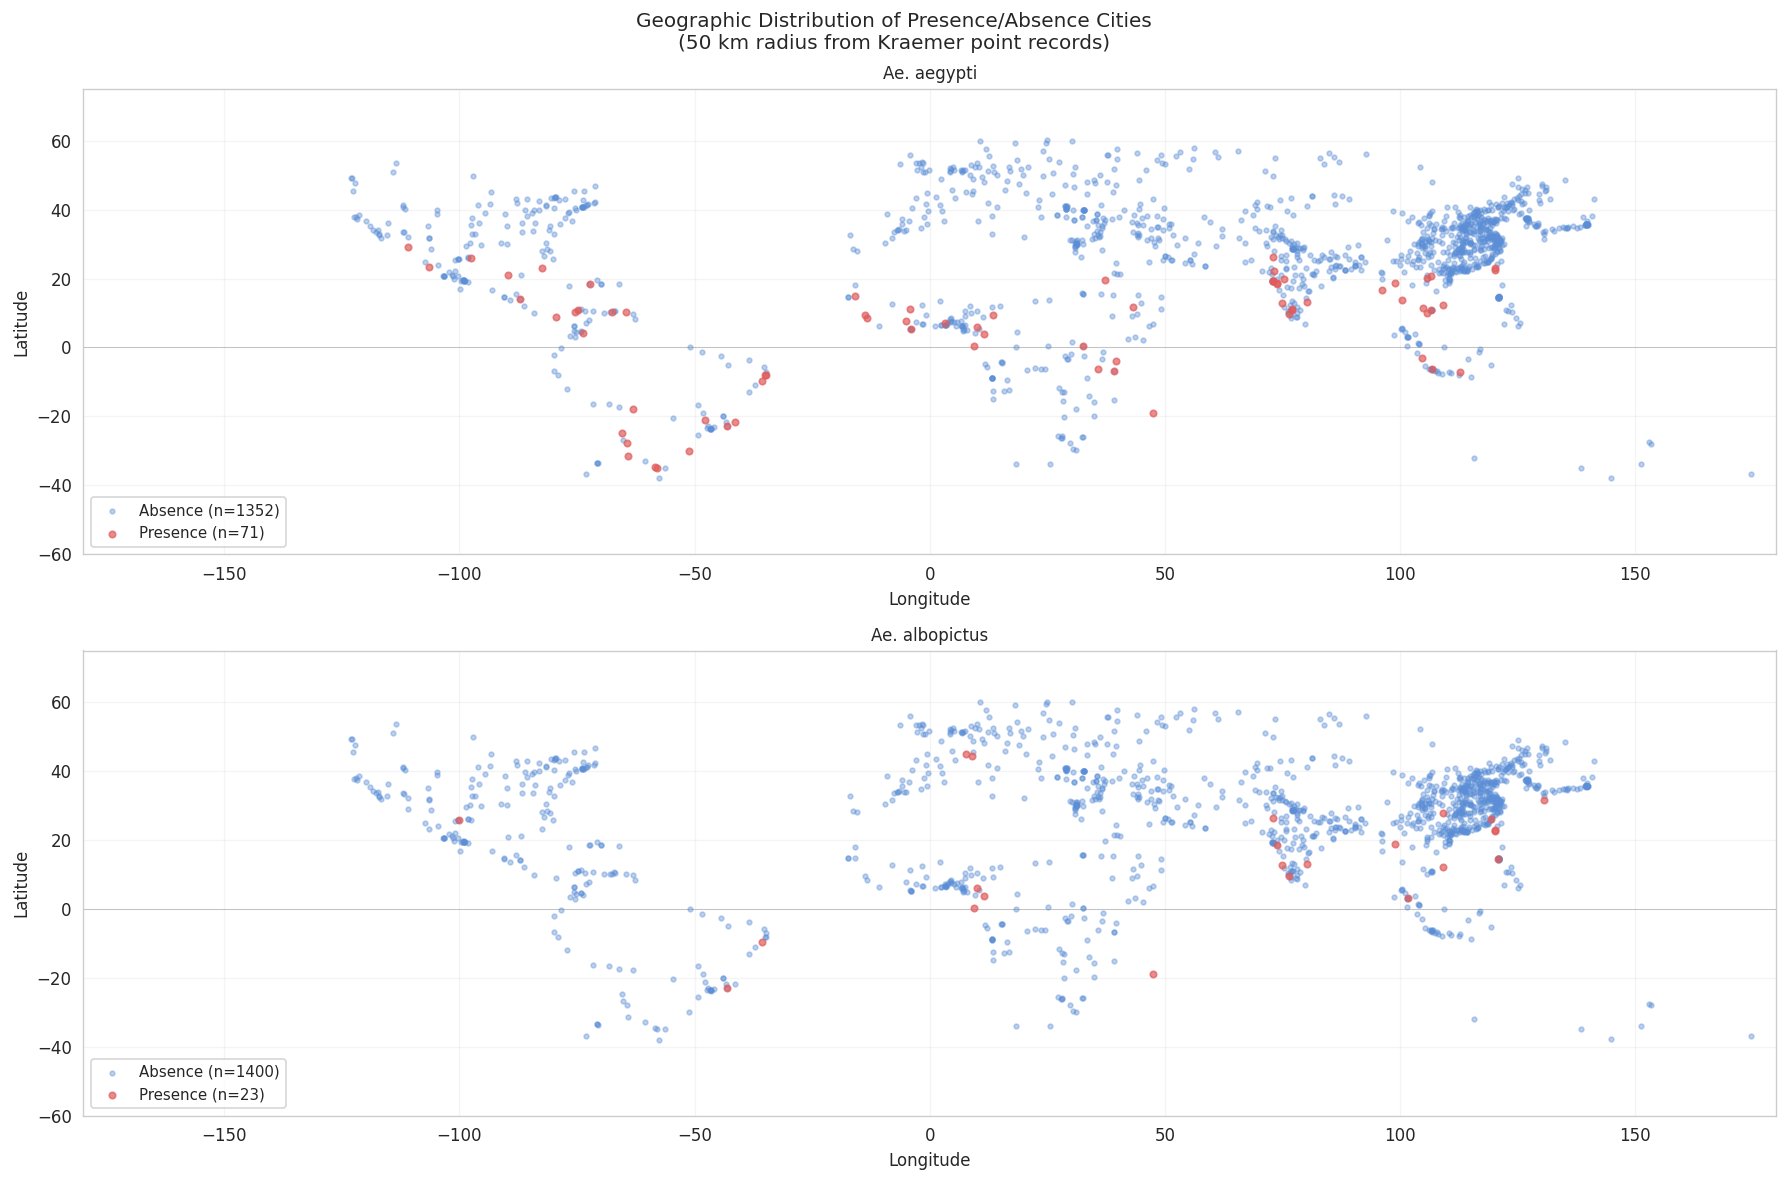

Saved: fig_04_geographic_sanity.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Geographic Distribution of Presence/Absence Cities\n(50 km radius from Kraemer point records)',
             fontsize=12)

for ax, (species_label, df) in zip(axes, [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]):
    pres = df[df['presence'] == 1]
    abs_ = df[df['presence'] == 0]

    ax.scatter(abs_['lon'], abs_['lat'], s=8, alpha=0.4, color='#5b8ed6', label=f'Absence (n={len(abs_)})', zorder=2)
    ax.scatter(pres['lon'], pres['lat'], s=15, alpha=0.7, color='#e05c5c', label=f'Presence (n={len(pres)})', zorder=3)

    ax.set_title(species_label, fontsize=10)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 75)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.axhline(0, color='grey', lw=0.5, alpha=0.5)
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('fig_04_geographic_sanity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_04_geographic_sanity.png')

### 11. False Negatives: High-Suitability Cities with No Kraemer Record

Cities labelled as absence here are more accurately understood as cities with no record in the validation dataset, not confirmed absence. Absence in Kraemer reflects coverage limitations of the validation layer, particularly in Southeast Asia and Africa, where surveillance intensity was uneven through 2014. These high-suitability cities are worth flagging as analytically interesting precisely because the model predicts suitability that the validation data cannot confirm or deny.

In [19]:
for species_label, df in [('Ae. aegypti', cities_aeg), ('Ae. albopictus', cities_alb)]:
    # High suitability but no Kraemer record within 50 km
    fn = df[(df['presence'] == 0) & (df['peak_score'] >= 0.6)].copy()
    fn = fn.sort_values('peak_score', ascending=False)
    print(f'\n{species_label}: high-suitability absence cities (peak >= 0.6): {len(fn)}')
    cols = ['city', 'country', 'lat', 'lon', 'peak_score', 'season_months_02', 'season_months_03', 'season_months_04']
    print(fn[cols].head(15).to_string(index=False))


Ae. aegypti: high-suitability absence cities (peak >= 0.6): 989
            city     country     lat      lon  peak_score  season_months_02  season_months_03  season_months_04
    Bhubaneshwar       India 20.2700  85.8400      1.0000                12                12                12
Ho Chi Minh City     Vietnam 10.7756 106.7019      0.9999                12                12                12
         Thủ Đức     Vietnam 10.8266 106.7609      0.9999                12                12                12
     Banjarmasin   Indonesia -3.3200 114.5925      0.9999                12                12                12
          Hezhou       China 24.4042 111.5672      0.9999                 7                 7                 6
         Guiping       China 23.4000 110.0833      0.9998                 9                 8                 7
         Meizhou       China 24.2890 116.1220      0.9996                 8                 8                 7
          Somolu     Nigeria  6.5408   

### 12. Interpretation Notes

**What the results show**
In this validation, season length is the strongest discriminator across all thresholds tested. For *Ae. aegypti*, AUC reaches 0.834 (season_months_02); for *Ae. albopictus*, 0.743. Both are comfortably above 0.70, a threshold often treated as acceptable discrimination in applied settings, though such thresholds are context-dependent. Ecological niche models generally produce lower AUC values than models with clean, confirmed absence data, in part because absence labels in sparse global datasets often reflect surveillance gaps rather than confirmed biological absence. Presence-labelled cities show a median of 12 active months (at ≥ 0.2 threshold) compared with 6 months for absence-labelled cities, indicating a clear and interpretable separation.

`mean_active_score` summarises the mean suitability across months that clear the 0.2 threshold only: it captures the quality of the active season, not a year-round average. Cities with short seasons but high within-season scores will differ from cities with long but moderate seasons, and both patterns are ecologically meaningful.

Peak score alone is weaker (AUC ~0.66–0.69), which is substantively plausible. Many subtropical cities without a Kraemer record still reach high peak suitability values, because absence in the validation layer often reflects incomplete surveillance coverage rather than confirmed biological absence.

**Important: this is a relative validation, not an absolute one**
These AUC values measure how well the suitability metrics separate presence-labelled from absence-labelled cities. They do not test against confirmed absences. The negative class is noisy: it mixes true negatives, unsampled locations, and places omitted from Kraemer due to geographic unevenness. Results should be interpreted as discrimination against a noisy background, not as definitive ecological validation.

**Key limitation: sampling bias in the validation data**
Presence rates are low: 71 presence cities (5.0%) for *Ae. aegypti* and 23 (1.6%) for *Ae. albopictus*. This mainly reflects coverage limitations of the Kraemer validation layer rather than a failure of the suitability model itself. The dataset compares 1,421 cities against a relatively limited and geographically uneven global record base up to 2014. Many cities labelled as absence, particularly in Southeast Asia and Africa, are more accurately understood as cities with no record in the validation dataset, not confirmed absence. This sampling bias in the validation data is a central caveat in interpreting all results.

**High-suitability absence-labelled cities** (Section 10) should be interpreted as either genuine undetected presences, or true absences despite suitable climate due to local factors such as elevation, land use, or lack of breeding habitat. This ambiguity is inherent to any presence-only validation framework.

## Discussion

### 13. Comparison with Independent Transmission Model (Tegar et al. 2026)

The seasonal suitability windows are broadly consistent with Tegar et al.'s (2026) independent transmission risk model for *Ae. albopictus*-borne chikungunya virus in Europe. Using a temperature-dependent R₀ model derived from PRISMA-guided empirical data on extrinsic incubation period and vector competence, Tegar et al. identify Germany and surrounding central European countries as moderately risky zones with 3–5 months of transmission suitability (May–September). In our model, at the Moderate threshold (0.3), major German cities show season lengths of 3 months, with peak activity falling in July, sitting at the lower end of the 3–5 month range identified by Tegar et al. At the Early warning threshold (0.2), more continental cities such as Berlin, Frankfurt, and Munich extend to 4 months, while at the Strict threshold (0.4), northern cities such as Hamburg contract to 2 months. This threshold sensitivity is expected, as season boundaries are determined by months where climatic suitability falls close to the threshold value.

Tegar et al. estimate a minimum cut-off temperature for chikungunya virus transmission by *Ae. albopictus* of 13.84°C (95% CI: 10.7–17.4°C), in line with the Tmin of 11.02°C used here for general activity suitability (Doeurk et al. 2025). The lower Tmin reflects that mosquito activity begins at temperatures below those required for virus transmission.
One limitation worth noting: the temperature optimum used here (Topt = 24.5°C) is derived from *female survival* in Doeurk et al. 2025, a single life-history trait. Tegar et al. find an optimum for chikungunya virus transmission of 25.63°C, integrating multiple traits (EIP, vector competence, biting rate, survival) into a full R₀ model. Doeurk et al. also report that blood-feeding rates in *Ae. albopictus* peak at 25°C, slightly above the survival optimum. This suggests the suitability curve used here may be marginally conservative around the peak

### 14. Photoperiod parameter Validation

The photoperiod thresholds applied in our model are independently corroborated by the Copernicus Climate Change Service (C3S) dataset on climatic suitability for *Ae. albopictus* in Europe (C3S, 2019). That dataset implements the seasonal activity model of Medlock et al. (2006), which defines egg hatching in spring as requiring photoperiod > 11.25 h and autumn diapause onset when photoperiod drops below 13.5 h, identical to the `PHOTO_LOW` and `PHOTO_HIGH` thresholds used here. Both thresholds originate from Lacour et al. (2015), who established the critical photoperiod (CPP) for diapause induction in a French Mediterranean *Ae. albopictus* population at 13.5 h, and identified 11.25 h as the minimum photoperiod required for spring egg hatching onset. The C3S model is restricted to Europe and based on climate projections (RCP4.5/8.5). Here we extend a comparable approach globally using ERA5 historical climate normals. This treatment of daylength as a seasonal constraint on activity outside the tropics is further supported by Bonizzoni et al. (2013), who document rapid adaptive evolution of critical photoperiod in temperate *Ae. albopictus* populations as a key driver of the species' range expansion into higher latitudes. The same thresholds are applied by Petrić et al. (2021), who implemented the Medlock et al. (2006) framework on ERA5 Land data across Europe and validated against VectorNet presence data.

### 15. Validation against urban ecology literature (Domdey & Thomas 2024)

Domdey & Thomas (2024) conducted a systematic literature review on *Ae. albopictus* in urban environments, compiled for the Bavarian State Office for Health as part of the TU München Centre for Urban Nature and Climate Adaptation. Several findings independently corroborate modelling decisions made here.

Outside the tropics, *Ae. albopictus* was detected from May to November across European studies, with peak abundance in August, consistent with the Moderate threshold (0.3) results for major German cities, which yield 3–4 active months centred on July–August. The review identifies 13–27°C as the optimal temperature range for urban *Ae. albopictus* populations, with egg-laying onset reported at 10.4°C (Romiti et al. 2021 in Domdey & Thomas), broadly consistent with the Tmin = 11.02°C and Early warning threshold (0.2) used here.

On urban heat islands, the review specifically identifies nocturnal heat islands as a key driver of establishment: stable nighttime water temperatures in urban microhabitats accelerate larval development and can sustain overwintering even at ambient temperatures well below −6°C. This supports the UHI limitation noted above. On precipitation, Domdey & Thomas find that urban Ae. albopictus populations are structurally decoupled from natural rainfall through artificial water sources, such as flowerpot saucers, rain barrels, gutter runoff and road drains, sustaining breeding habitat independently of precipitation even in arid periods. This limits the predictive value of VPD-based moisture scoring in highly urbanised contexts, consistent with the precipitation limitation noted in the Suitability Model section.

### 16. Confirmed Distribution in Europe (ECDC 2025)

ECDC surveillance ([June 2025](https://www.ecdc.europa.eu/en/publications-data/aedes-aegypti-current-known-distribution-june-2025)) confirms that within the EU, *Ae. aegypti* is established only in Cyprus (Simonin 2025) and on the island of Madeira (Portugal), despite climate suitability extending across parts of mainland southern Europe. Both locations fall below 500,000 population but are included as special interest cities with full suitability scores.

*Ae. albopictus*, by contrast, is established in 369 regions across countries within the EU, including Germany ([ECDC, June 2025](https://www.ecdc.europa.eu/en/publications-data/aedes-albopictus-current-known-distribution-june-2025)), consistent with the broader suitability windows modelled here. The year 2025 marked an unprecedented level of arboviral circulation in Europe, with locally acquired cases of chikungunya, dengue, and West Nile virus recorded simultaneously across the continent (Simonin 2025).

The gap between *Ae. aegypti* climate suitability and confirmed EU establishment illustrates a key limitation of climate-only models: suitable conditions are necessary but not sufficient for establishment. Barriers such as introduction history, competitive exclusion, and surveillance coverage all contribute to the observed distribution.

### 17. Model Limitations

- **Climate normals (1991–2020):** Recent warming trends may shift actual suitability windows. Comparing 1991–2020 vs. 2001–2030 normals would show whether recent warming has already shifted season boundaries. The 2001–2030 WMO reference period will not be fully available until around 2031. A shorter period such as 2011–2024 would reduce comparability because of unequal period length, while 2001–2024 overlaps with the current baseline by 20 years and would likely limit detection of a meaningful shift.
- **Interannual variability:** Suitability scores are derived from 30-year monthly climate normals, which represent average conditions and smooth out year-to-year variability. Anomalous years such as an unusually wet August in an otherwise dry city or an exceptionally warm spring are not captured. The model describes structural seasonal suitability, not the outbreak-relevant variability that drives actual population surges in specific years.
- **Spatial resolution:** Suitability is modelled for individual cities, not across continuous space. This makes exposed-population estimates methodologically unsound at the city level. Meaningful exposure analysis would require gridded population data (e.g. GHS-POP) combined with spatially continuous suitability fields, which lies beyond the scope of the current dataset.
- **Urban heat island effect:** ERA5 climate data are provided at ~31 km spatial resolution, representing regional climate conditions rather than urban surface temperatures. Cities are systematically warmer than surrounding areas, typically by 1–3°C depending on city size, density, and season. Suitability scores may therefore underestimate urban seasonal windows in dense urban centres, where the effective thermal environment can sustain mosquito activity beyond what ERA5-derived temperatures suggest.​​​​​​​​​​​​​​​​
- **Urban decoupling from precipitation (*Ae. albopictus*):** The VPD score captures moisture constraints under natural conditions, but urban *Ae. albopictus* populations are substantially decoupled from ambient humidity and precipitation through artificial water sources, such as rain barrels, gutter runoff, road drains, and flower pot saucers provide stable breeding habitat independently of rainfall (Domdey & Thomas 2024). In highly urbanised cities, the VPD component may therefore underweight suitability during dry, and season length metrics may be more reliable discriminators than peak score in dense urban contexts.
- **Suitability scores reflect climate conditions, not confirmed presence.** Thermal and humidity constraints are captured based on lower thermal thresholds (Doeurk et al. 2025) and vapor pressure deficit (VPD) limits (Lacour et al. 2015), but biotic factors such as prior establishment, competitive dynamics, or human-mediated introduction are not. Where temperatures approach the lower thermal threshold, occurrence records can diverge substantially from climate predictions, as documented for example in Mexico City (~2,242 m), where *Ae. aegypti* persists despite conditions near its thermal minimum (Lozano-Fuentes et al. 2012; Dávalos-Becerril et al. 2019; Ortega-Morales et al. 2022); in Bogotá (~2,625 m), where isolated detections were reported at bus stations in 2023 to 2024 (Villamizar-Gomez et al. 2025); and in the Arequipa region (~2,350 m), where first field evidence emerged in 2016 (Requena-Zúñiga et al. 2018).
- **Latitudinal photoperiod transition (*Ae. albopictus*):** The binary ∣lat∣≥23.5∘ cutoff has been replaced with a sigmoid transition (inflection = 23.5∘, k=0.5), eliminating edge-case artefacts near the tropics boundary (e.g. São Paulo vs. Rio de Janeiro). The sigmoid produces a ∼8.8∘ transition zone. The slope parameter k=0.5 is a modelling assumption and has not been empirically tuned to field data.
- **Seasonal photoperiod trigger (*Ae. albopictus*):** Within non-tropical zones, diapause onset is modelled as a binary threshold at 13.5 h daylength (Lacour et al. 2015). In reality, diapause induction is a gradual population-level response that varies with local adaptation. The 13.5 h threshold is derived from a French Mediterranean population and its applicability globally is uncertain. Urbanski et al. (2012) demonstrate that critical photoperiod in Ae. albopictus varies latitudinally and has undergone rapid adaptive evolution across ∼15∘ of latitude in the United States. A sigmoid daylength function could better reflect this biological reality and is a potential refinement.
- **Species-specific temperature parameters:** All thermal thresholds (Tmin, Topt, Tmax) for both species were taken from Doeurk et al. (2025), who fitted a quadratic survival model to Cambodian field populations and reported explicit threshold values that can be directly mapped to a triangular suitability curve. This source was preferred over Schmidt et al. (2018), whose Cox regression approach provides relative hazard estimates rather than absolute thermal thresholds. For *Ae. albopictus*, the resulting Topt of 24.5 °C is approximately 3 °C higher than the 21.5 °C reported by Schmidt et al. (2018) from a pooled analysis of globally diverse laboratory strains. This difference may reflect local thermal adaptation in tropical populations as well as differences in study design and strain composition.
- **Presence data:** Suitability scores have been validated against occurrence records from Kraemer et al. (2015), consistent with the methodology described in the Model Validation section. Further comparison against the Mosquito Alert citizen science platform or the VectorMap database (Laporta et al. 2023) could extend coverage, particularly for post-2014 records.
- **City size threshold:** Only cities with populations ≥ 500,000 are included in the main pipeline.
   Funchal (Madeira) and Nicosia (Cyprus), the only two EU territories with confirmed *Ae. aegypti* establishment, are added as special interest cities and appear in the dashboard with full suitability scores.

### 18. Future Directions

- **Virus-specific transmission modelling:** This work models general climate suitability for mosquito activity. A natural extension would be to incorporate virus-specific temperature–trait relationships (EIP, vector competence) to estimate transmission risk for specific arboviruses, as demonstrated for chikungunya by Tegar et al. (2026) and for dengue/Zika by Mordecai et al. (2017).
- **From suitability to outbreak forecasting:** Integrating confirmed case data would add a predictive layer on top of suitability scores, an approach demonstrated at country level by Sebastianelli et al. (2024) for dengue in Brazil and Peru ([ESA-PhiLab/ESA-UNICEF_DengueForecastProject](https://github.com/ESA-PhiLab/ESA-UNICEF_DengueForecastProject)).
- **Higher-resolution climate input:** ERA5-Land (9 km) would better capture urban
  heat island effects and complex terrain compared to the ERA5 grid used here (~31 km).
  Statistical downscaling using machine learning (e.g. Random Forest or CNN-based approaches
  trained on elevation, land cover, and coastal proximity) could extend resolution further,
  improving suitability estimates in dense urban centres and high-elevation cities.

### 19. References

>Bonizzoni M, et al. The invasive mosquito species *Aedes albopictus*: current knowledge and future perspectives. Trends Parasitol. 2013; 29(9):460–468. https://doi.org/10.1016/j.pt.2013.07.003

>Copernicus Climate Change Service (C3S) Climate Data Store (CDS). (2019). Climatic suitability for the presence and seasonal activity of the *Aedes albopictus* mosquito for Europe derived from climate projections. https://doi.org/10.24381/cds.d08ed09a

>Dávalos-Becerril E, et al. Urban and semi-urban mosquitoes of Mexico City: A risk for endemic mosquito-borne disease transmission. PLOS ONE 2019; 14(3): e0212987. https://doi.org/10.1371/journal.pone.0212987

>Doeurk S, et al. Impact of temperature on survival, development and longevity of *Ae. aegypti* and *Ae. albopictus*. Parasites & Vectors 2025; 18:362. https://doi.org/10.1186/s13071-025-06892-y

>Domdey A, Thomas S. Asiatische Tigermücke in Städten: Grundlagen für urbane Klimaanpassungsmaßnahmen und die Gesundheitsvorsorge. Begleitstudie zum Vorhaben Moskito des Bayer. LGL, Teilprojekt 17 des Zentrums Stadtnatur und Klimaanpassung. Technische Universität München / Universität Bayreuth; 27. Juni 2024.

>Hersbach H, et al. ERA5 monthly averaged data on single levels from 1940 to present. Copernicus Climate Change Service (C3S) Climate Data Store (CDS) 2023. https://doi.org/10.24381/cds.f17050d7

>Kraemer MUG, et al. The global compendium of *Aedes aegypti* and *Ae. albopictus* occurrence. Sci Data 2015; 2:150035. https://doi.org/10.1038/sdata.2015.35

>Lacour G, et al. Seasonal Synchronization of Diapause Phases in *Aedes albopictus* (Diptera: Culicidae). PLOS ONE 2015; 10(12): e0145311. https://doi.org/10.1371/journal.pone.0145311

>Laporta GZ, et al. Global Distribution of *Aedes aegypti* and *Aedes albopictus* in a Climate Change Scenario of Regional Rivalry. Insects 2023; 14:49. https://doi.org/10.3390/insects14010049

>Lozano-Fuentes S, et al. The dengue virus mosquito vector *Aedes aegypti* at high elevation in México. American Journal of Tropical Medicine and Hygiene 2012; 87(5):902–909. https://doi.org/10.4269/ajtmh.2012.12-0244

>Medlock JM, et al. Analysis of the potential for survival and seasonal activity of *Aedes albopictus* (Diptera: Culicidae) in the United Kingdom. Journal of Vector Ecology 2006; 31(2):292–304. https://doi.org/10.3376/1081-1710(2006)31[292:AOTPFS]2.0.CO;2

>Mordecai EA, et al. Detecting the impact of temperature on transmission of Zika, dengue, and chikungunya using mechanistic models. PLOS Neglected Tropical Diseases 2017; 11(4): e0005568. https://doi.org/10.1371/journal.pntd.0005568

>Ortega-Morales AI, et al. Update on the dispersal of *Aedes albopictus* in Mexico: 1988–2021. Frontiers in Tropical Diseases 2022; 2:814205. https://doi.org/10.3389/fitd.2021.814205

>Petrić M, et al. Seasonality and timing of peak abundance of Aedes albopictus in Europe: Implications to public and animal health. Geospatial Health 2021; 16:996. https://doi.org/10.4081/gh.2021.996

>Requena-Zúñiga E, et al. Primera evidencia de *Aedes aegypti* en la región de Arequipa, Perú 2016. Rev Peru Med Exp Salud Publica 2018; 35(2):348–9. https://doi.org/10.17843/rpmesp.2018.352.3557

>Schmidt CA, et al. Effects of desiccation stress on adult female longevity in *Ae. aegypti* and *Ae. albopictus*. Parasites & Vectors 2018; 11:267. https://doi.org/10.1186/s13071-018-2808-6

>Sebastianelli A, et al. A reproducible ensemble machine learning approach to forecast dengue outbreaks. Scientific Reports 2024; 14:3807. https://doi.org/10.1038/s41598-024-52796-9

>Simonin Y. Europe Faces Multiple Arboviral Threats in 2025. Viruses 2025; 17:1642. https://doi.org/10.3390/v17121642

>Tegar S, et al. Temperature-sensitive incubation, transmissibility and risk of *Aedes albopictus*-borne chikungunya virus in Europe. J. R. Soc. Interface 2026; 23:20250707. https://doi.org/10.1098/rsif.2025.0707

>Urbanski J, et al. Rapid adaptive evolution of photoperiodic response during invasion and range expansion across a climatic gradient. Am Nat. 2012; 179(4):490–500. https://doi.org/10.1086/664709

>Villamizar Gomez A, et al. *Aedes aegypti* mosquito detection at bus stations, Bogota, Colombia, 2023–2024. Emerg Infect Dis 2025; 31(6):1256–7. https://doi.org/10.3201/eid3106.241052